# Exploratory Data Analysis: Beverage Sales Dataset

**Author:** Robert Moreno  
**Dataset:** sales_drinks.csv  

Comprehensive analysis of beverage retail transactions including sales patterns, customer behavior, product performance, and revenue insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Dataset Overview

In [ ]:
df = pd.read_csv('sales_drinks.csv')
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
df.head(3)

Dataset Shape: 1,834,174 rows × 11 columns



,invoice_id,customer_id,purchase_datetime,sku,quantity,unit_price,discount_pct,amount,product_name,brand,category
0,100322793,966889,2025-02-02 17:40:49,43852960,3,12.00,0.00,36.00,Cerveza Pilsener Rubia Light 12 x 355 ml,Pilsener,beer_cider
1,100322793,966889,2025-02-02 17:40:49,41108238,2,5.35,0.00,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
2,100159021,966889,2025-04-20 19:09:16,40217487,3,6.89,0.00,20.67,Cerveza Club Premium Clásica Botella (330 ml) ...,Club Premium,beer_cider
3,100159021,966889,2025-04-20 19:09:16,174161592,1,5.98,0.00,5.98,Cerveza Heineken Lata Pack (269 ml) 6 Unidades,Heineken,beer_cider
4,100159021,966889,2025-04-20 19:09:16,41108238,2,5.35,0.00,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
5,100159021,966889,2025-04-20 19:09:16,41108238,3,5.35,0.00,16.05,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
6,100370051,966889,2025-05-13 05:25:42,194888104,3,14.58,0.00,43.74,Cerveza Pilsener (12 Unidades) 473 ml,Pilsener,beer_cider
7,100370051,966889,2025-05-13 05:25:42,41108238,2,5.35,0.00,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
8,100370051,966889,2025-05-13 05:25:42,182060952,5,17.16,0.00,85.80,Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Si...,Corona,beer_cider
9,100370051,966889,2025-05-13 05:25:42,41108238,2,5.35,0.00,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834174 entries, 0 to 1834173
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   invoice_id         int64  
 1   customer_id        int64  
 2   purchase_datetime  object 
 3   sku                int64  
 4   quantity           int64  
 5   unit_price         float64
 6   discount_pct       float64
 7   amount             float64
 8   product_name       object 
 9   brand              object 
 10  category           object 
dtypes: float64(3), int64(4), object(4)
memory usage: 153.9+ MB


In [4]:
df.describe()

,invoice_id,customer_id,sku,quantity,unit_price,discount_pct,amount
count,1834174.00,1834174.00,1834174.00,1834174.00,1834174.00,1834174.00,1834174.00
mean,100185506.41,550199.72,84033520.70,6.94,7.57,2.88,40.52
std,107087.65,258927.22,61422227.56,13.24,4.83,6.04,84.77
min,100000000.00,100000.00,40213687.00,1.00,0.25,0.00,0.25
25%,100092563.00,325838.00,40668863.00,2.00,5.35,0.00,11.00
50%,100185439.00,550238.00,41108238.00,3.00,5.35,0.00,19.42
75%,100278251.75,773974.00,164767261.00,5.00,8.70,0.00,34.32
max,100370999.00,999982.00,196978063.00,208.00,43.11,25.00,3692.55


In [5]:
# Parse datetime
df['purchase_datetime'] = pd.to_datetime(df['purchase_datetime'])
df['date'] = df['purchase_datetime'].dt.date
df['year'] = df['purchase_datetime'].dt.year
df['month'] = df['purchase_datetime'].dt.month
df['day'] = df['purchase_datetime'].dt.day
df['hour'] = df['purchase_datetime'].dt.hour
df['dayofweek'] = df['purchase_datetime'].dt.dayofweek
df['weekday_name'] = df['purchase_datetime'].dt.day_name()

print("✓ Datetime features extracted")

✓ Datetime features extracted


## 2. Data Quality Assessment

In [6]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

print("Missing Values Summary:\n")
missing_summary[missing_summary['Missing_Count'] > 0]

Missing Values Summary:



,Missing_Count,Missing_Percentage


In [7]:
# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

# Unique values
print(f"\nUnique counts:")
print(f"  Invoices: {df['invoice_id'].nunique():,}")
print(f"  Customers: {df['customer_id'].nunique():,}")
print(f"  Products (SKU): {df['sku'].nunique():,}")
print(f"  Brands: {df['brand'].nunique():,}")
print(f"  Categories: {df['category'].nunique():,}")

Duplicate rows: 138,645

Unique counts:
  Invoices: 371,000
  Customers: 53,000
  Products (SKU): 145
  Brands: 56
  Categories: 8


In [8]:
# Data quality checks
print("Data Quality Checks:\n")
print(f"Negative quantities: {(df['quantity'] < 0).sum():,}")
print(f"Negative prices: {(df['unit_price'] < 0).sum():,}")
print(f"Negative amounts: {(df['amount'] < 0).sum():,}")
print(f"Discount > 100%: {(df['discount_pct'] > 100).sum():,}")
print(f"Discount < 0%: {(df['discount_pct'] < 0).sum():,}")

Data Quality Checks:

Negative quantities: 0
Negative prices: 0
Negative amounts: 0
Discount > 100%: 0
Discount < 0%: 0


## 3. Sales Overview

In [9]:
# Key metrics
total_revenue = df['amount'].sum()
total_transactions = df['invoice_id'].nunique()
total_items_sold = df['quantity'].sum()
avg_transaction_value = df.groupby('invoice_id')['amount'].sum().mean()
avg_items_per_transaction = df.groupby('invoice_id')['quantity'].sum().mean()
avg_unit_price = df['unit_price'].mean()

print("="*60)
print("SALES PERFORMANCE SUMMARY")
print("="*60)
print(f"Total Revenue:              ${total_revenue:,.2f}")
print(f"Total Transactions:         {total_transactions:,}")
print(f"Total Items Sold:           {total_items_sold:,}")
print(f"Avg Transaction Value:      ${avg_transaction_value:,.2f}")
print(f"Avg Items per Transaction:  {avg_items_per_transaction:.2f}")
print(f"Avg Unit Price:             ${avg_unit_price:.2f}")
print("="*60)

SALES PERFORMANCE SUMMARY
Total Revenue:              $74,313,273.42
Total Transactions:         371,000
Total Items Sold:           12,721,147
Avg Transaction Value:      $200.31
Avg Items per Transaction:  34.29
Avg Unit Price:             $7.57


## 4. Univariate Analysis

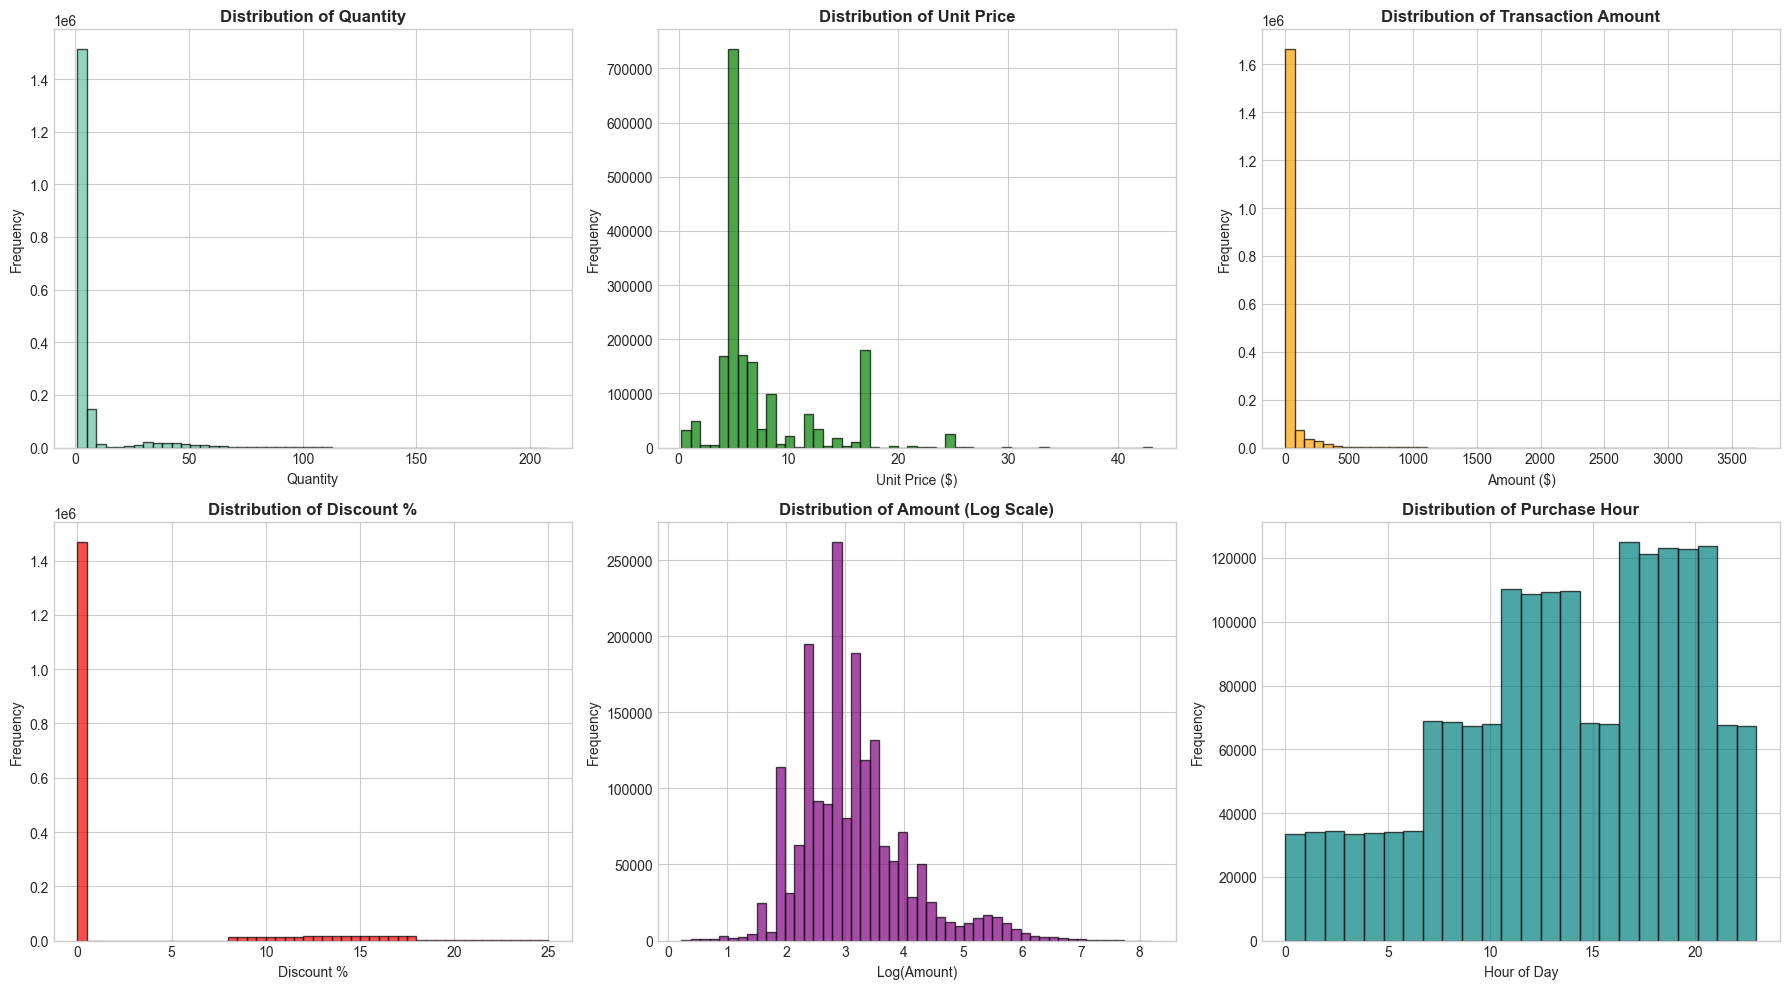

In [10]:
# Numerical distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Quantity
axes[0,0].hist(df['quantity'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribution of Quantity', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Quantity')
axes[0,0].set_ylabel('Frequency')

# Unit Price
axes[0,1].hist(df['unit_price'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0,1].set_title('Distribution of Unit Price', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Unit Price ($)')
axes[0,1].set_ylabel('Frequency')

# Amount
axes[0,2].hist(df['amount'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,2].set_title('Distribution of Transaction Amount', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Amount ($)')
axes[0,2].set_ylabel('Frequency')

# Discount
axes[1,0].hist(df['discount_pct'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1,0].set_title('Distribution of Discount %', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Discount %')
axes[1,0].set_ylabel('Frequency')

# Log scale for amount
axes[1,1].hist(np.log1p(df['amount']), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1,1].set_title('Distribution of Amount (Log Scale)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Log(Amount)')
axes[1,1].set_ylabel('Frequency')

# Hour of day
axes[1,2].hist(df['hour'], bins=24, edgecolor='black', alpha=0.7, color='teal')
axes[1,2].set_title('Distribution of Purchase Hour', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Hour of Day')
axes[1,2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

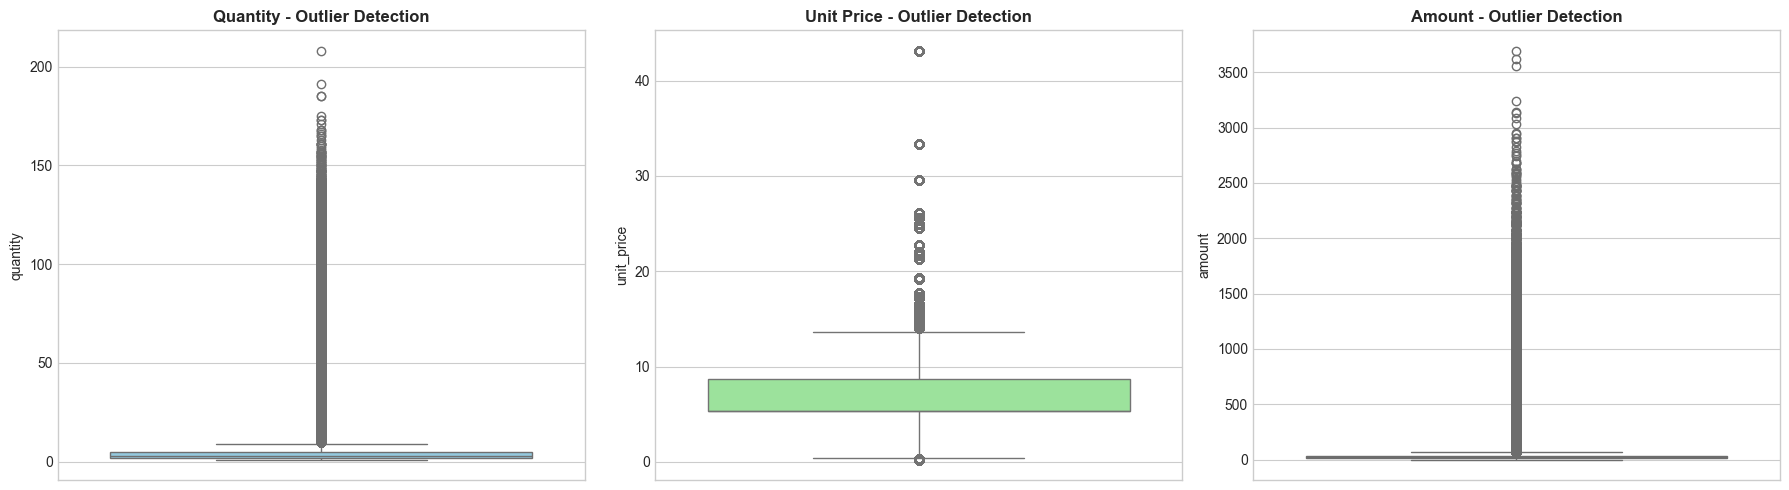

In [11]:
# Boxplots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Quantity - Outlier Detection', fontsize=12, fontweight='bold')

sns.boxplot(y=df['unit_price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Unit Price - Outlier Detection', fontsize=12, fontweight='bold')

sns.boxplot(y=df['amount'], ax=axes[2], color='salmon')
axes[2].set_title('Amount - Outlier Detection', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Temporal Analysis

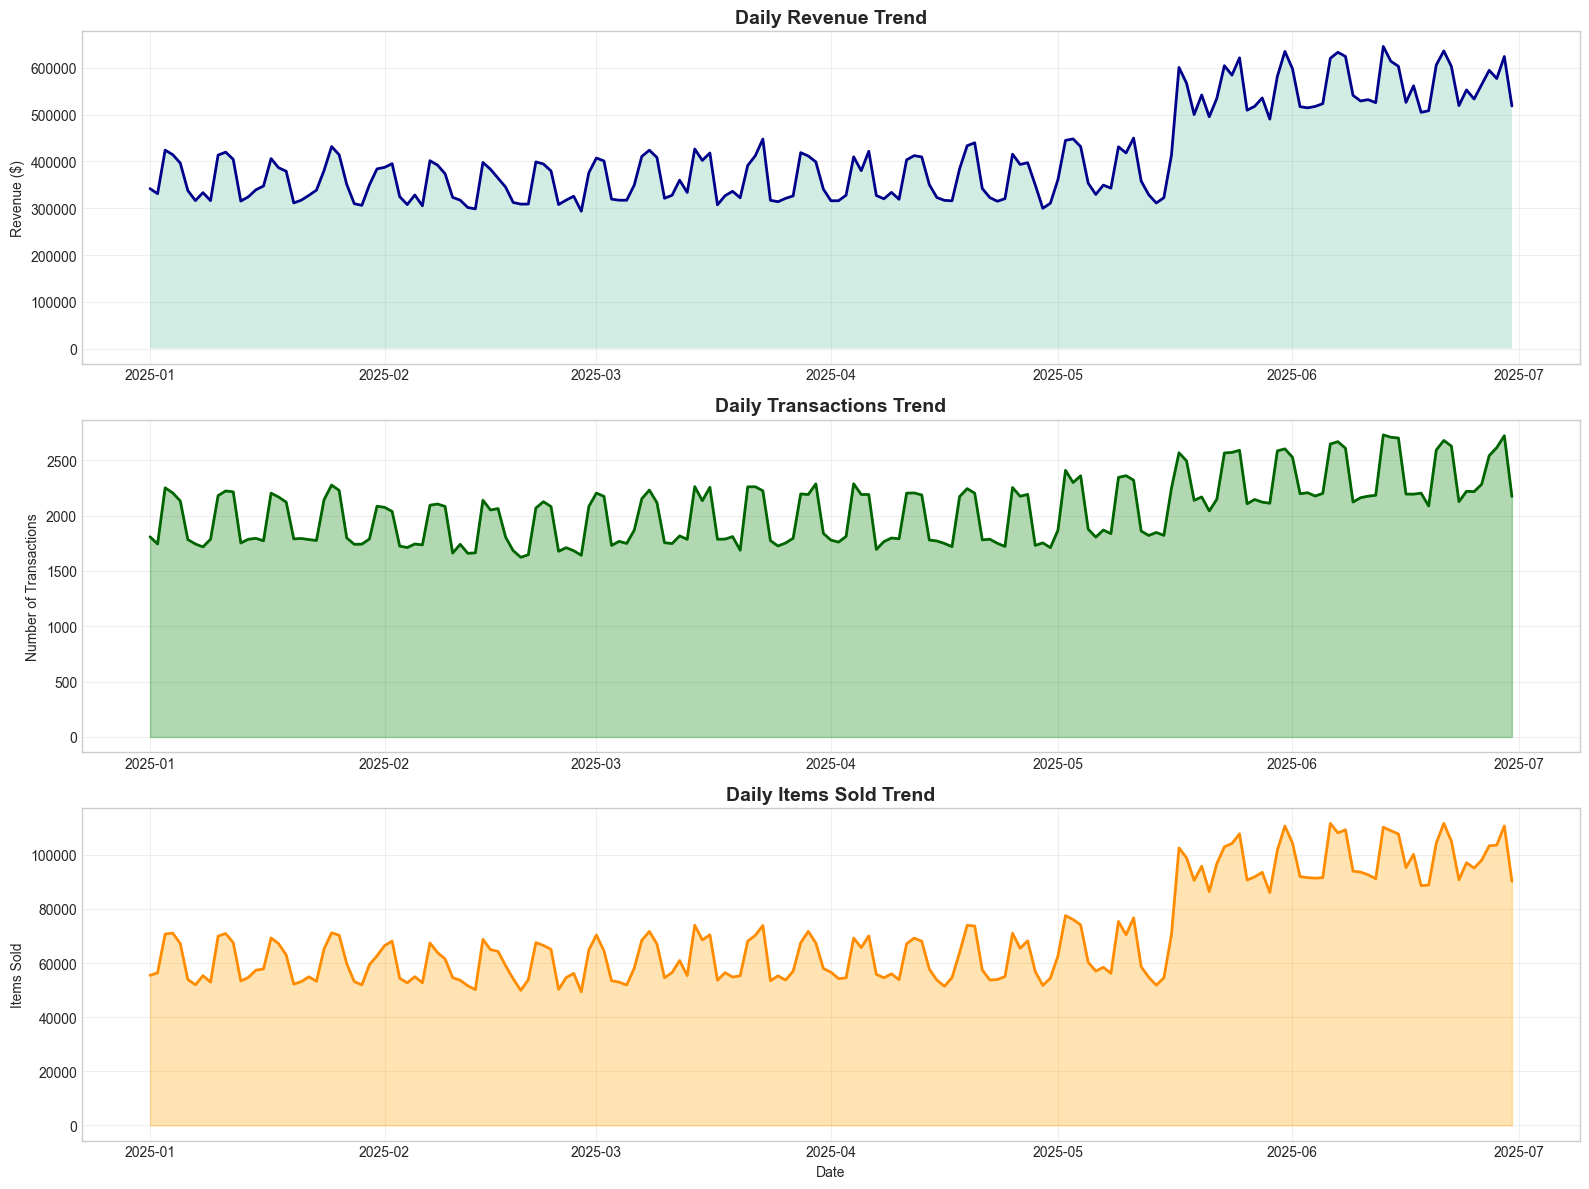

In [12]:
# Daily sales trend
daily_sales = df.groupby('date').agg({
    'amount': 'sum',
    'invoice_id': 'nunique',
    'quantity': 'sum'
}).reset_index()

daily_sales.columns = ['date', 'revenue', 'transactions', 'items_sold']

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Revenue trend
axes[0].plot(daily_sales['date'], daily_sales['revenue'], linewidth=2, color='darkblue')
axes[0].fill_between(daily_sales['date'], daily_sales['revenue'], alpha=0.3)
axes[0].set_title('Daily Revenue Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(alpha=0.3)

# Transactions trend
axes[1].plot(daily_sales['date'], daily_sales['transactions'], linewidth=2, color='darkgreen')
axes[1].fill_between(daily_sales['date'], daily_sales['transactions'], alpha=0.3, color='green')
axes[1].set_title('Daily Transactions Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
axes[1].grid(alpha=0.3)

# Items sold trend
axes[2].plot(daily_sales['date'], daily_sales['items_sold'], linewidth=2, color='darkorange')
axes[2].fill_between(daily_sales['date'], daily_sales['items_sold'], alpha=0.3, color='orange')
axes[2].set_title('Daily Items Sold Trend', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Items Sold')
axes[2].set_xlabel('Date')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

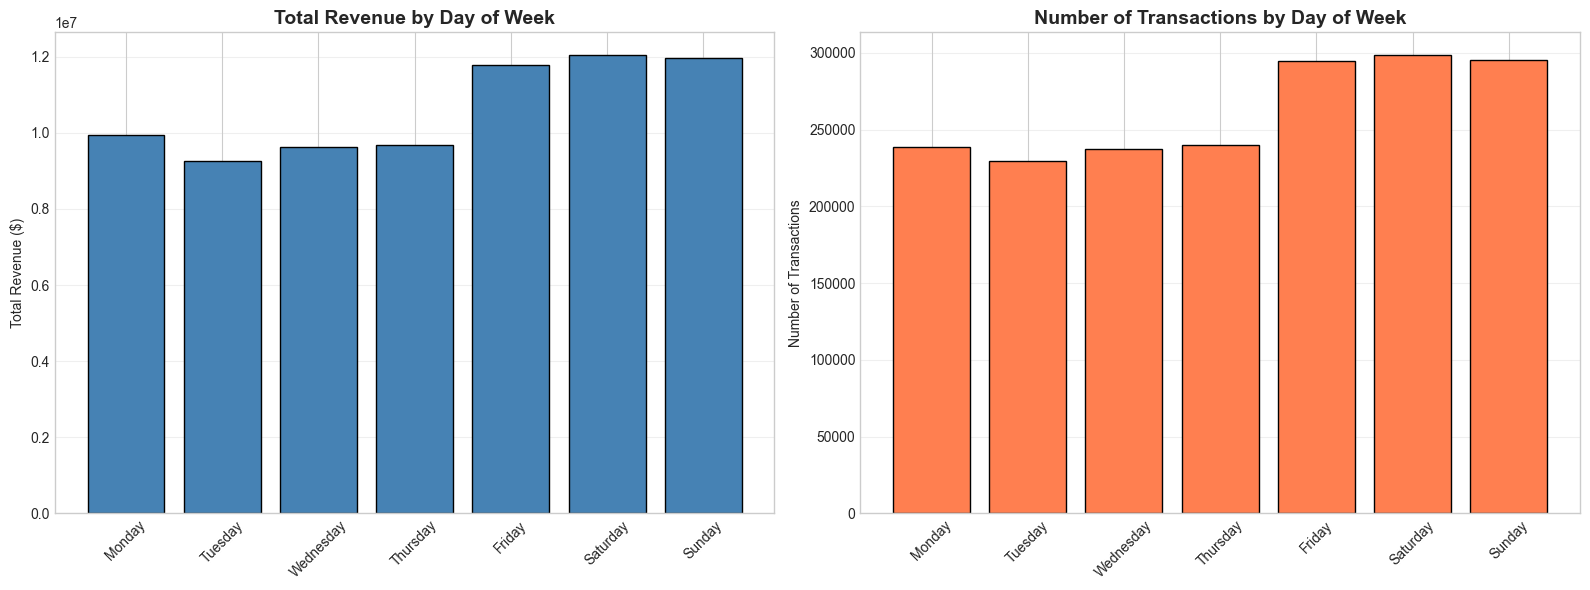

In [13]:
# Sales by day of week
weekday_sales = df.groupby('weekday_name')['amount'].agg(['sum', 'mean', 'count']).reset_index()
weekday_sales.columns = ['weekday', 'total_revenue', 'avg_transaction', 'num_transactions']

# Order by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales['weekday'] = pd.Categorical(weekday_sales['weekday'], categories=day_order, ordered=True)
weekday_sales = weekday_sales.sort_values('weekday')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by weekday
axes[0].bar(weekday_sales['weekday'], weekday_sales['total_revenue'], color='steelblue', edgecolor='black')
axes[0].set_title('Total Revenue by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Transactions by weekday
axes[1].bar(weekday_sales['weekday'], weekday_sales['num_transactions'], color='coral', edgecolor='black')
axes[1].set_title('Number of Transactions by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

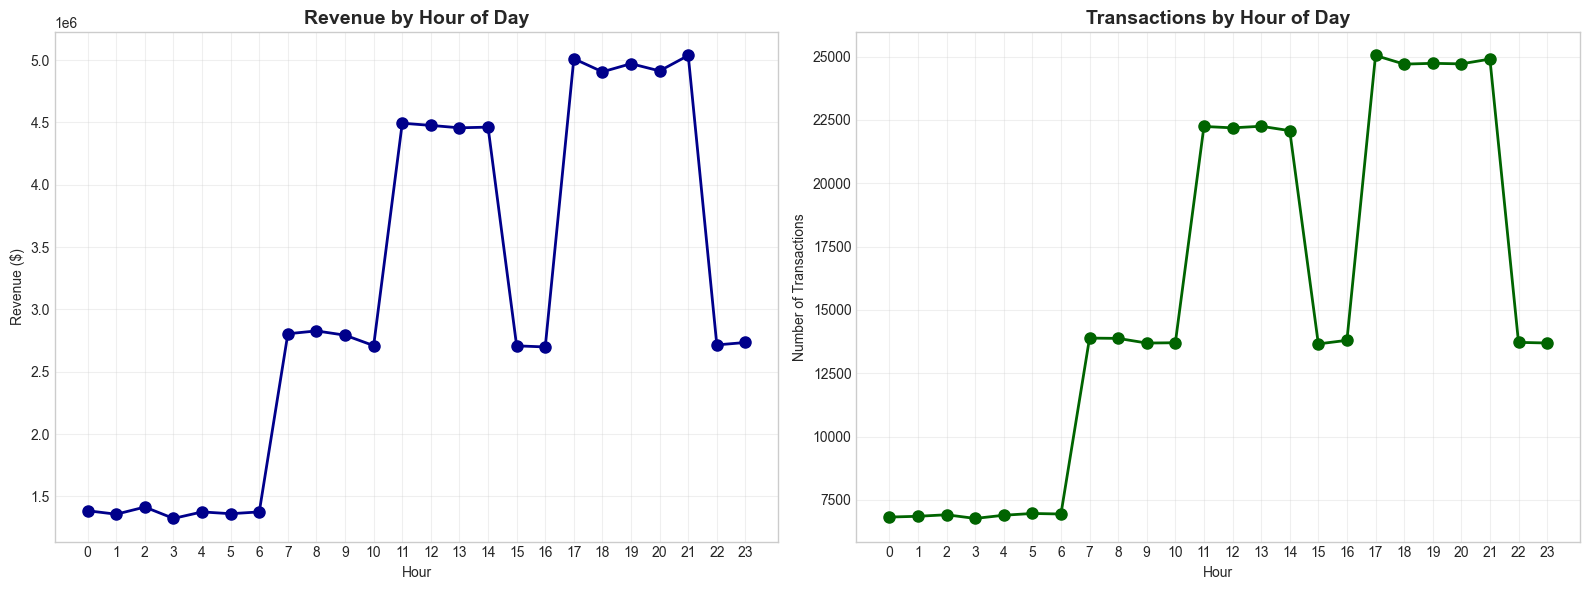

In [14]:
# Sales by hour of day
hourly_sales = df.groupby('hour').agg({
    'amount': 'sum',
    'invoice_id': 'nunique'
}).reset_index()

hourly_sales.columns = ['hour', 'revenue', 'transactions']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hourly_sales['hour'], hourly_sales['revenue'], marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0].set_title('Revenue by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(0, 24))

axes[1].plot(hourly_sales['hour'], hourly_sales['transactions'], marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1].set_title('Transactions by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Transactions')
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

## 6. Product Analysis

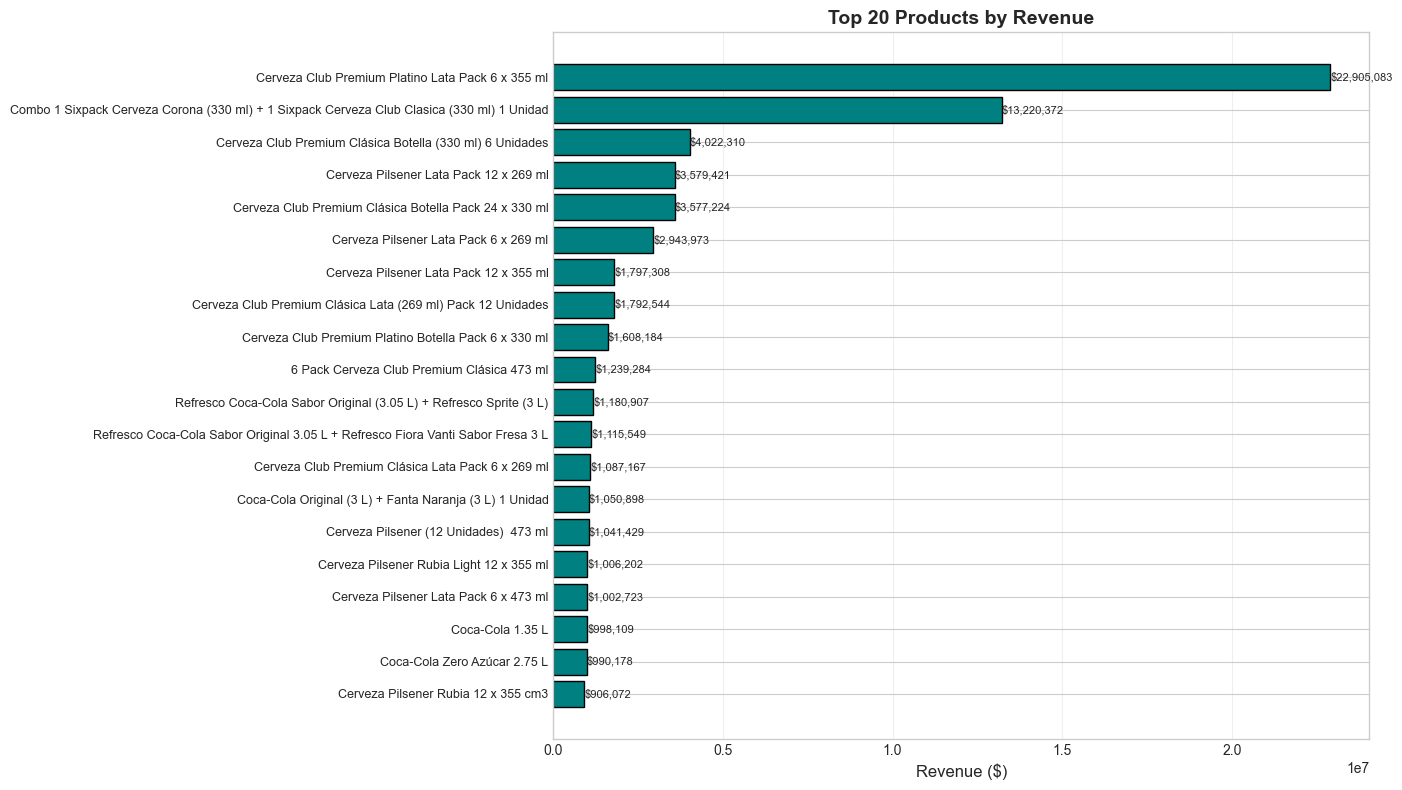

In [15]:
# Top 20 products by revenue
product_revenue = df.groupby('product_name').agg({
    'amount': 'sum',
    'quantity': 'sum',
    'invoice_id': 'nunique'
}).reset_index()

product_revenue.columns = ['product', 'revenue', 'units_sold', 'num_transactions']
product_revenue = product_revenue.sort_values('revenue', ascending=False)

top_20_products = product_revenue.head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_20_products)), top_20_products['revenue'], color='teal', edgecolor='black')
ax.set_yticks(range(len(top_20_products)))
ax.set_yticklabels(top_20_products['product'], fontsize=9)
ax.set_xlabel('Revenue ($)', fontsize=12)
ax.set_title('Top 20 Products by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_20_products['revenue']):
    ax.text(v + 500, i, f'${v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

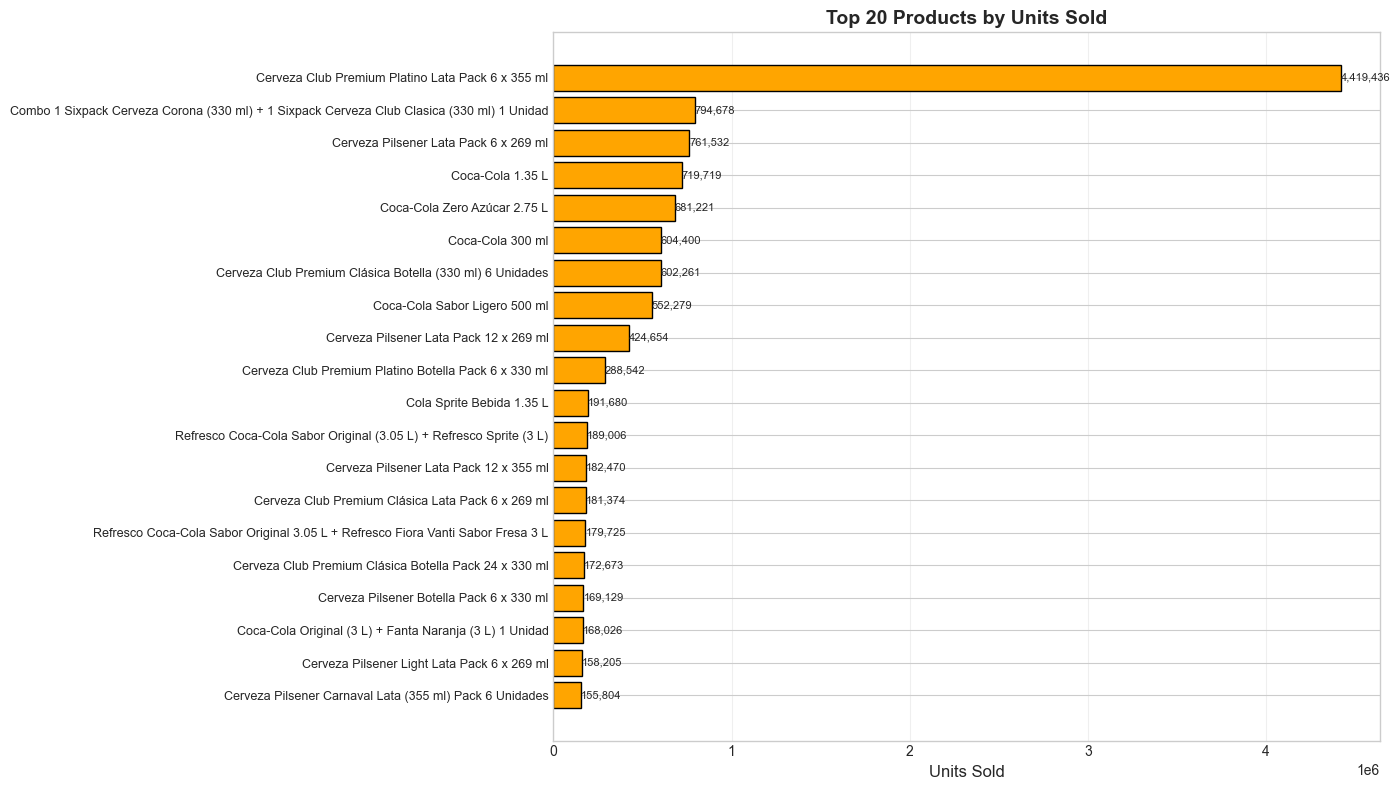

In [16]:
# Top 20 products by units sold
top_20_units = product_revenue.sort_values('units_sold', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_20_units)), top_20_units['units_sold'], color='orange', edgecolor='black')
ax.set_yticks(range(len(top_20_units)))
ax.set_yticklabels(top_20_units['product'], fontsize=9)
ax.set_xlabel('Units Sold', fontsize=12)
ax.set_title('Top 20 Products by Units Sold', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_20_units['units_sold']):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Category & Brand Analysis

In [17]:
# Category performance
category_stats = df.groupby('category').agg({
    'amount': 'sum',
    'quantity': 'sum',
    'invoice_id': 'nunique',
    'unit_price': 'mean'
}).reset_index()

category_stats.columns = ['category', 'revenue', 'units_sold', 'transactions', 'avg_price']
category_stats = category_stats.sort_values('revenue', ascending=False)

print("Category Performance:\n")
category_stats

Category Performance:



,category,revenue,units_sold,transactions,avg_price
0,beer_cider,64680511.23,9113072,344127,7.66
4,soft_drinks_mixers,6263647.29,3300051,37575,1.97
5,spirits,1918637.24,138730,32504,14.54
7,wine_sparkling_wine,1311727.66,120539,35800,11.23
3,pre_mixed,81594.19,14009,4484,6.00
1,juice_ice_tea_sports_energy,24996.11,17882,5751,1.44
6,water,21794.03,15916,5043,1.43
2,milk,10365.67,948,293,11.37


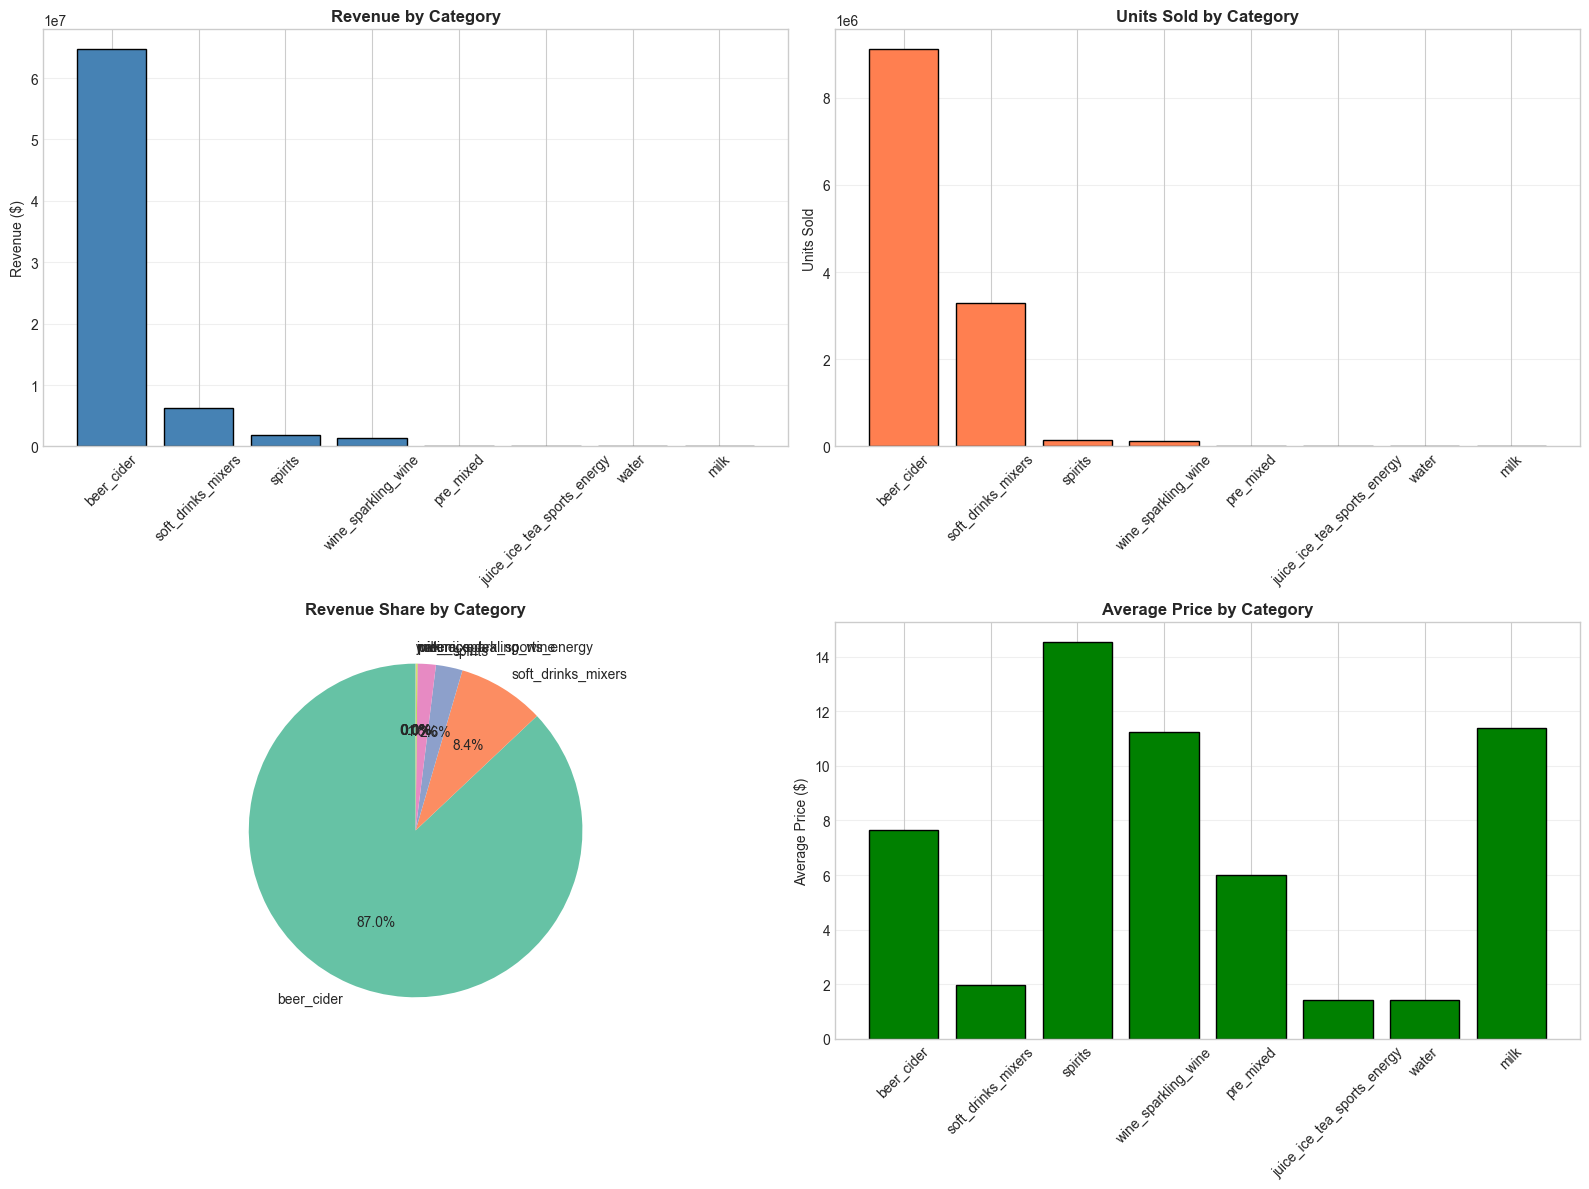

In [18]:
# Category visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Revenue by category
axes[0,0].bar(category_stats['category'], category_stats['revenue'], color='steelblue', edgecolor='black')
axes[0,0].set_title('Revenue by Category', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)

# Units sold by category
axes[0,1].bar(category_stats['category'], category_stats['units_sold'], color='coral', edgecolor='black')
axes[0,1].set_title('Units Sold by Category', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Units Sold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# Pie chart - revenue share
axes[1,0].pie(category_stats['revenue'], labels=category_stats['category'], autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Revenue Share by Category', fontsize=12, fontweight='bold')

# Average price by category
axes[1,1].bar(category_stats['category'], category_stats['avg_price'], color='green', edgecolor='black')
axes[1,1].set_title('Average Price by Category', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Average Price ($)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

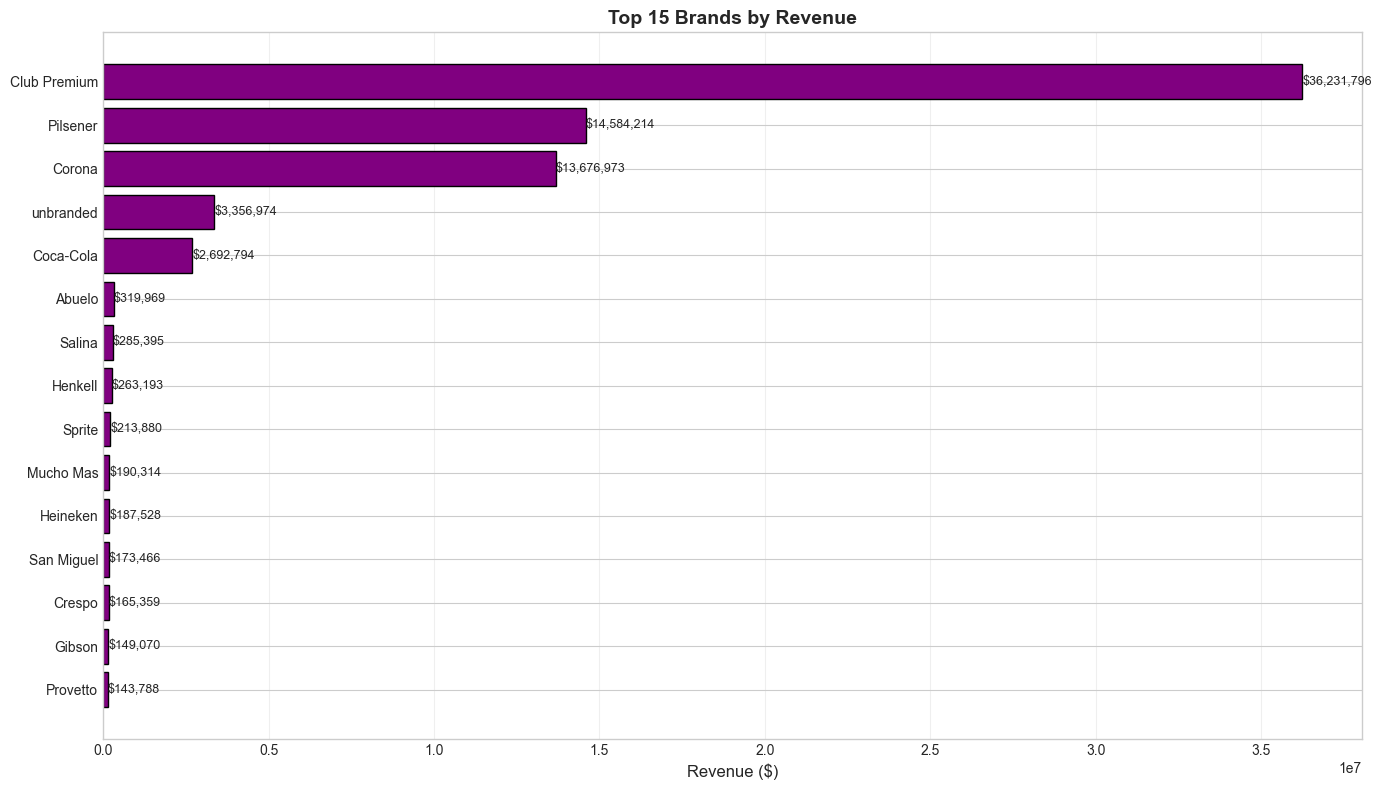

In [19]:
# Top 15 brands by revenue
brand_stats = df.groupby('brand').agg({
    'amount': 'sum',
    'quantity': 'sum',
    'invoice_id': 'nunique'
}).reset_index()

brand_stats.columns = ['brand', 'revenue', 'units_sold', 'transactions']
brand_stats = brand_stats.sort_values('revenue', ascending=False)

top_15_brands = brand_stats.head(15)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_15_brands)), top_15_brands['revenue'], color='purple', edgecolor='black')
ax.set_yticks(range(len(top_15_brands)))
ax.set_yticklabels(top_15_brands['brand'])
ax.set_xlabel('Revenue ($)', fontsize=12)
ax.set_title('Top 15 Brands by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_15_brands['revenue']):
    ax.text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Customer Analysis

In [20]:
# Customer behavior metrics
customer_stats = df.groupby('customer_id').agg({
    'invoice_id': 'nunique',
    'amount': 'sum',
    'quantity': 'sum'
}).reset_index()

customer_stats.columns = ['customer_id', 'num_purchases', 'total_spent', 'total_items']
customer_stats['avg_order_value'] = customer_stats['total_spent'] / customer_stats['num_purchases']

print("Customer Statistics:\n")
customer_stats.describe()

Customer Statistics:



,customer_id,num_purchases,total_spent,total_items,avg_order_value
count,53000.00,53000.00,53000.00,53000.00,53000.00
mean,549898.91,7.00,1402.14,240.02,134.77
std,259752.39,9.95,5480.94,1031.63,98.90
min,100000.00,1.00,2.80,1.00,2.80
25%,325083.00,2.00,242.29,32.00,86.55
50%,549591.50,4.00,486.93,64.00,116.62
75%,774975.50,7.00,894.37,117.00,154.43
max,999982.00,134.00,102984.59,16291.00,1239.04


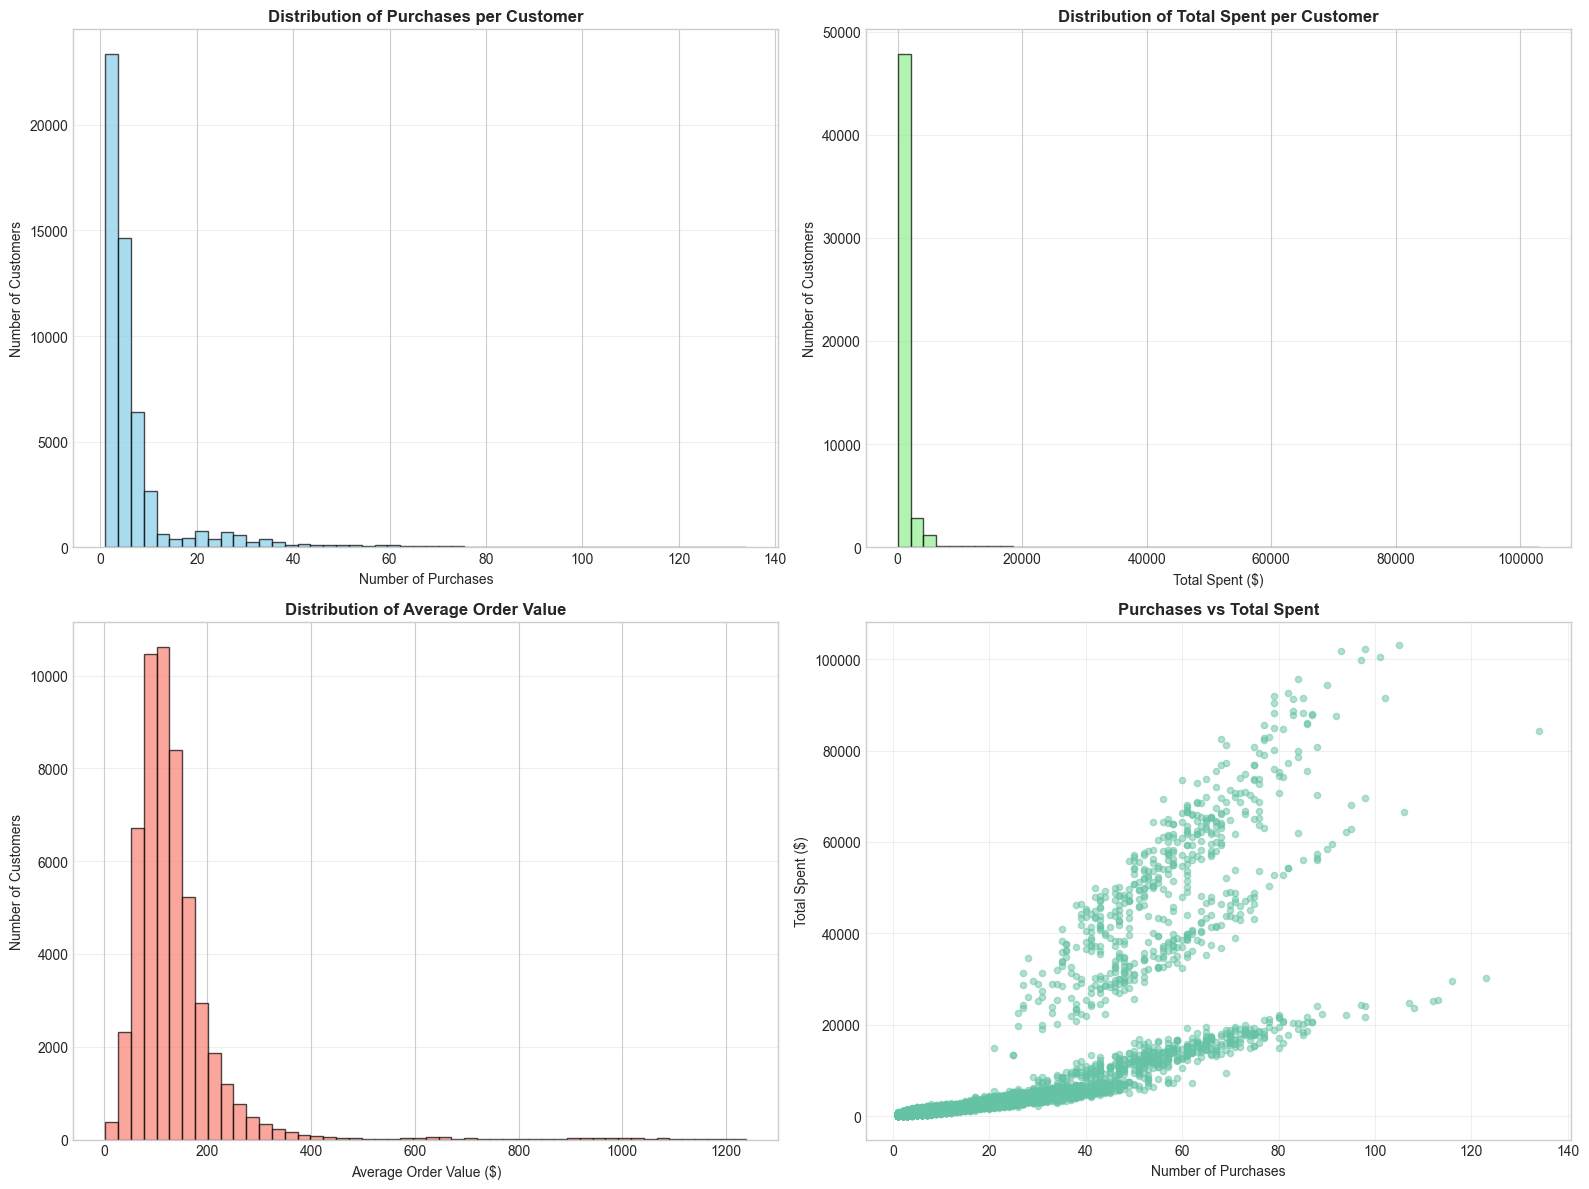

In [21]:
# Customer segmentation by purchase frequency
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of purchases per customer
axes[0,0].hist(customer_stats['num_purchases'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0,0].set_title('Distribution of Purchases per Customer', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Number of Purchases')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].grid(axis='y', alpha=0.3)

# Distribution of total spent per customer
axes[0,1].hist(customer_stats['total_spent'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0,1].set_title('Distribution of Total Spent per Customer', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Total Spent ($)')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].grid(axis='y', alpha=0.3)

# Distribution of average order value
axes[1,0].hist(customer_stats['avg_order_value'], bins=50, edgecolor='black', alpha=0.7, color='salmon')
axes[1,0].set_title('Distribution of Average Order Value', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Average Order Value ($)')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].grid(axis='y', alpha=0.3)

# Scatter: Purchases vs Total Spent
axes[1,1].scatter(customer_stats['num_purchases'], customer_stats['total_spent'], alpha=0.5, s=20)
axes[1,1].set_title('Purchases vs Total Spent', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Number of Purchases')
axes[1,1].set_ylabel('Total Spent ($)')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

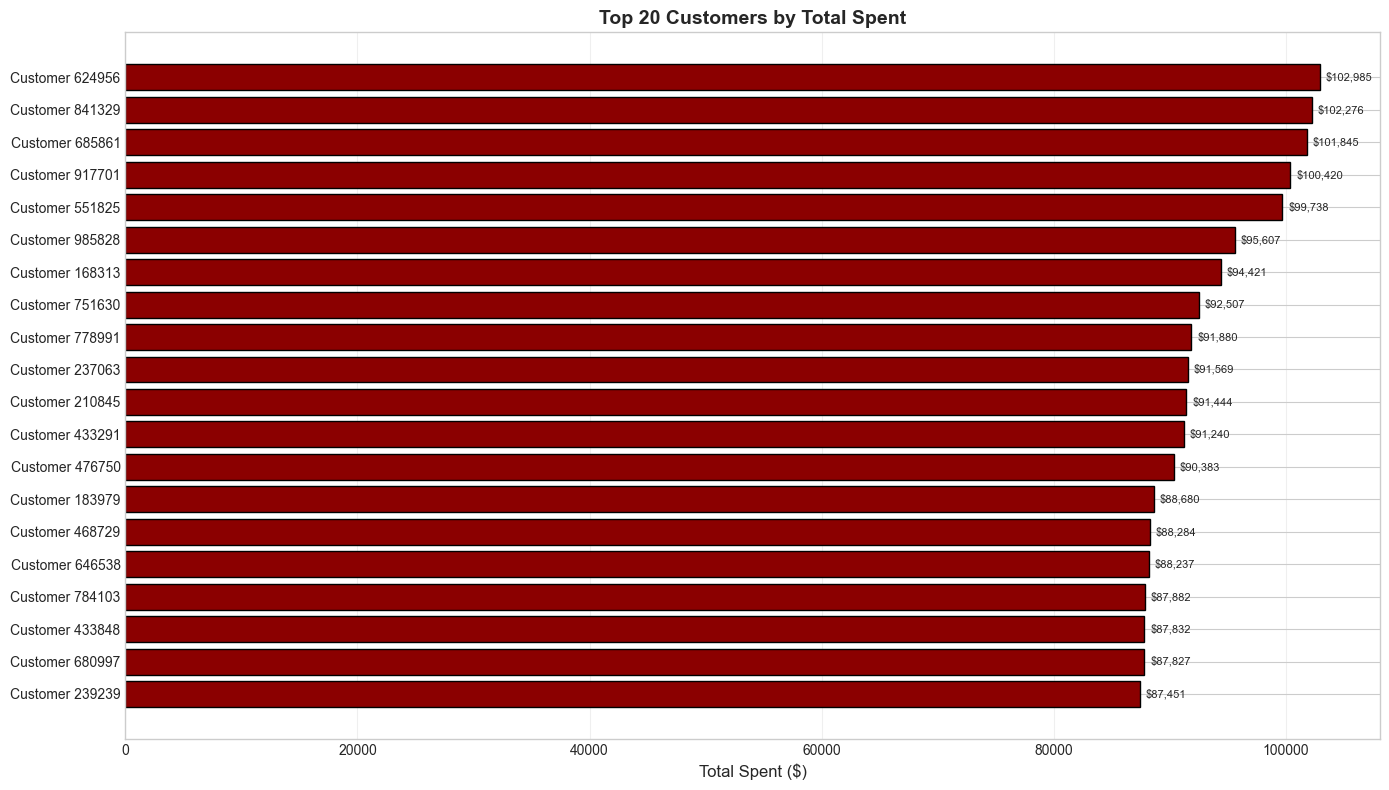

In [22]:
# Top 20 customers by revenue
top_20_customers = customer_stats.sort_values('total_spent', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_20_customers)), top_20_customers['total_spent'], color='darkred', edgecolor='black')
ax.set_yticks(range(len(top_20_customers)))
ax.set_yticklabels([f'Customer {c}' for c in top_20_customers['customer_id']])
ax.set_xlabel('Total Spent ($)', fontsize=12)
ax.set_title('Top 20 Customers by Total Spent', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_20_customers['total_spent']):
    ax.text(v + 500, i, f'${v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Discount Analysis

In [23]:
# Discount statistics
discount_stats = df[df['discount_pct'] > 0]

print(f"Transactions with discount: {len(discount_stats):,} ({len(discount_stats)/len(df)*100:.2f}%)")
print(f"Average discount when applied: {discount_stats['discount_pct'].mean():.2f}%")
print(f"Max discount: {df['discount_pct'].max():.2f}%")
print(f"\nRevenue with discount: ${discount_stats['amount'].sum():,.2f}")
print(f"Revenue without discount: ${df[df['discount_pct'] == 0]['amount'].sum():,.2f}")

Transactions with discount: 366,834 (20.00%)
Average discount when applied: 14.42%
Max discount: 25.00%

Revenue with discount: $21,334,332.82
Revenue without discount: $52,978,940.60


In [24]:
# Discount impact on sales
df['has_discount'] = df['discount_pct'] > 0

discount_comparison = df.groupby('has_discount').agg({
    'amount': ['sum', 'mean', 'count'],
    'quantity': 'sum'
}).round(2)

discount_comparison.columns = ['total_revenue', 'avg_transaction', 'num_transactions', 'total_units']
discount_comparison.index = ['No Discount', 'With Discount']

print("\nDiscount Impact Analysis:\n")
discount_comparison


Discount Impact Analysis:



,total_revenue,avg_transaction,num_transactions,total_units
No Discount,52978940.60,36.11,1467340,9142037
With Discount,21334332.82,58.16,366834,3579110


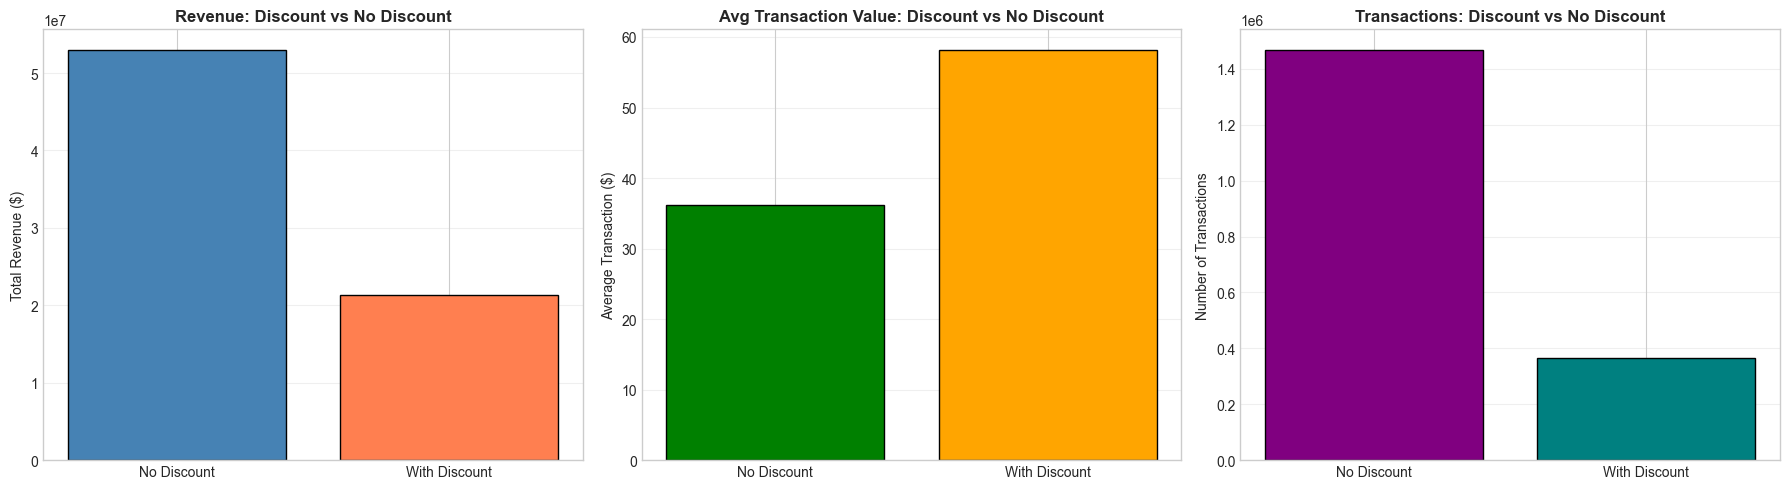

In [25]:
# Visualize discount impact
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue comparison
axes[0].bar(discount_comparison.index, discount_comparison['total_revenue'], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Revenue: Discount vs No Discount', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].grid(axis='y', alpha=0.3)

# Average transaction
axes[1].bar(discount_comparison.index, discount_comparison['avg_transaction'], color=['green', 'orange'], edgecolor='black')
axes[1].set_title('Avg Transaction Value: Discount vs No Discount', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Transaction ($)')
axes[1].grid(axis='y', alpha=0.3)

# Number of transactions
axes[2].bar(discount_comparison.index, discount_comparison['num_transactions'], color=['purple', 'teal'], edgecolor='black')
axes[2].set_title('Transactions: Discount vs No Discount', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Transactions')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

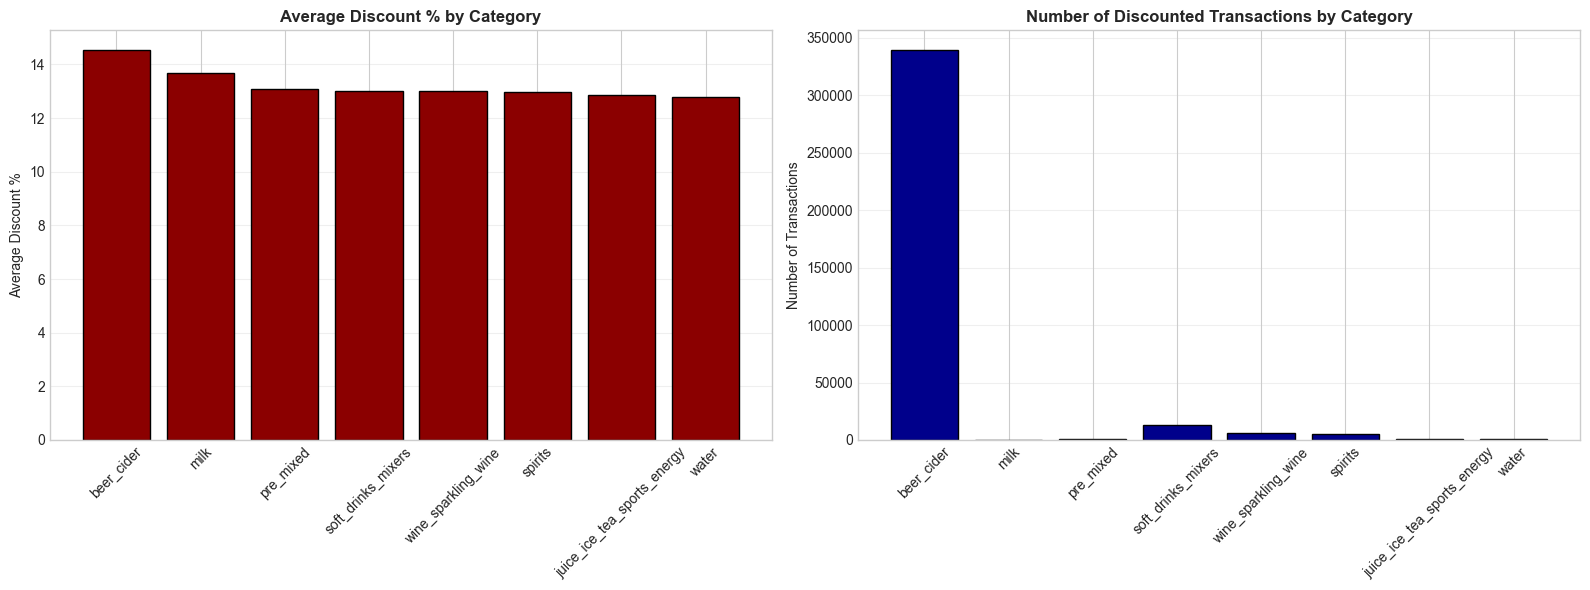

In [26]:
# Discount distribution by category
category_discount = df[df['discount_pct'] > 0].groupby('category')['discount_pct'].agg(['mean', 'count']).reset_index()
category_discount.columns = ['category', 'avg_discount', 'num_discounted']
category_discount = category_discount.sort_values('avg_discount', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(category_discount['category'], category_discount['avg_discount'], color='darkred', edgecolor='black')
axes[0].set_title('Average Discount % by Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Discount %')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(category_discount['category'], category_discount['num_discounted'], color='darkblue', edgecolor='black')
axes[1].set_title('Number of Discounted Transactions by Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Correlation Analysis

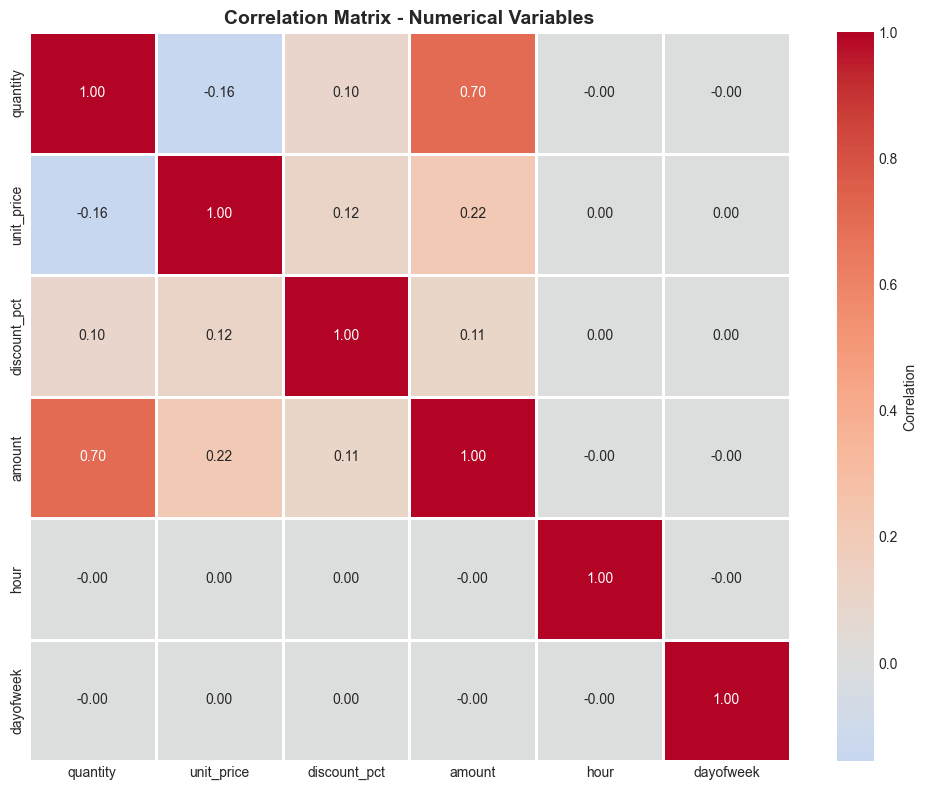

In [27]:
# Correlation matrix
numeric_cols = ['quantity', 'unit_price', 'discount_pct', 'amount', 'hour', 'dayofweek']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            linewidths=1, linecolor='white', cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

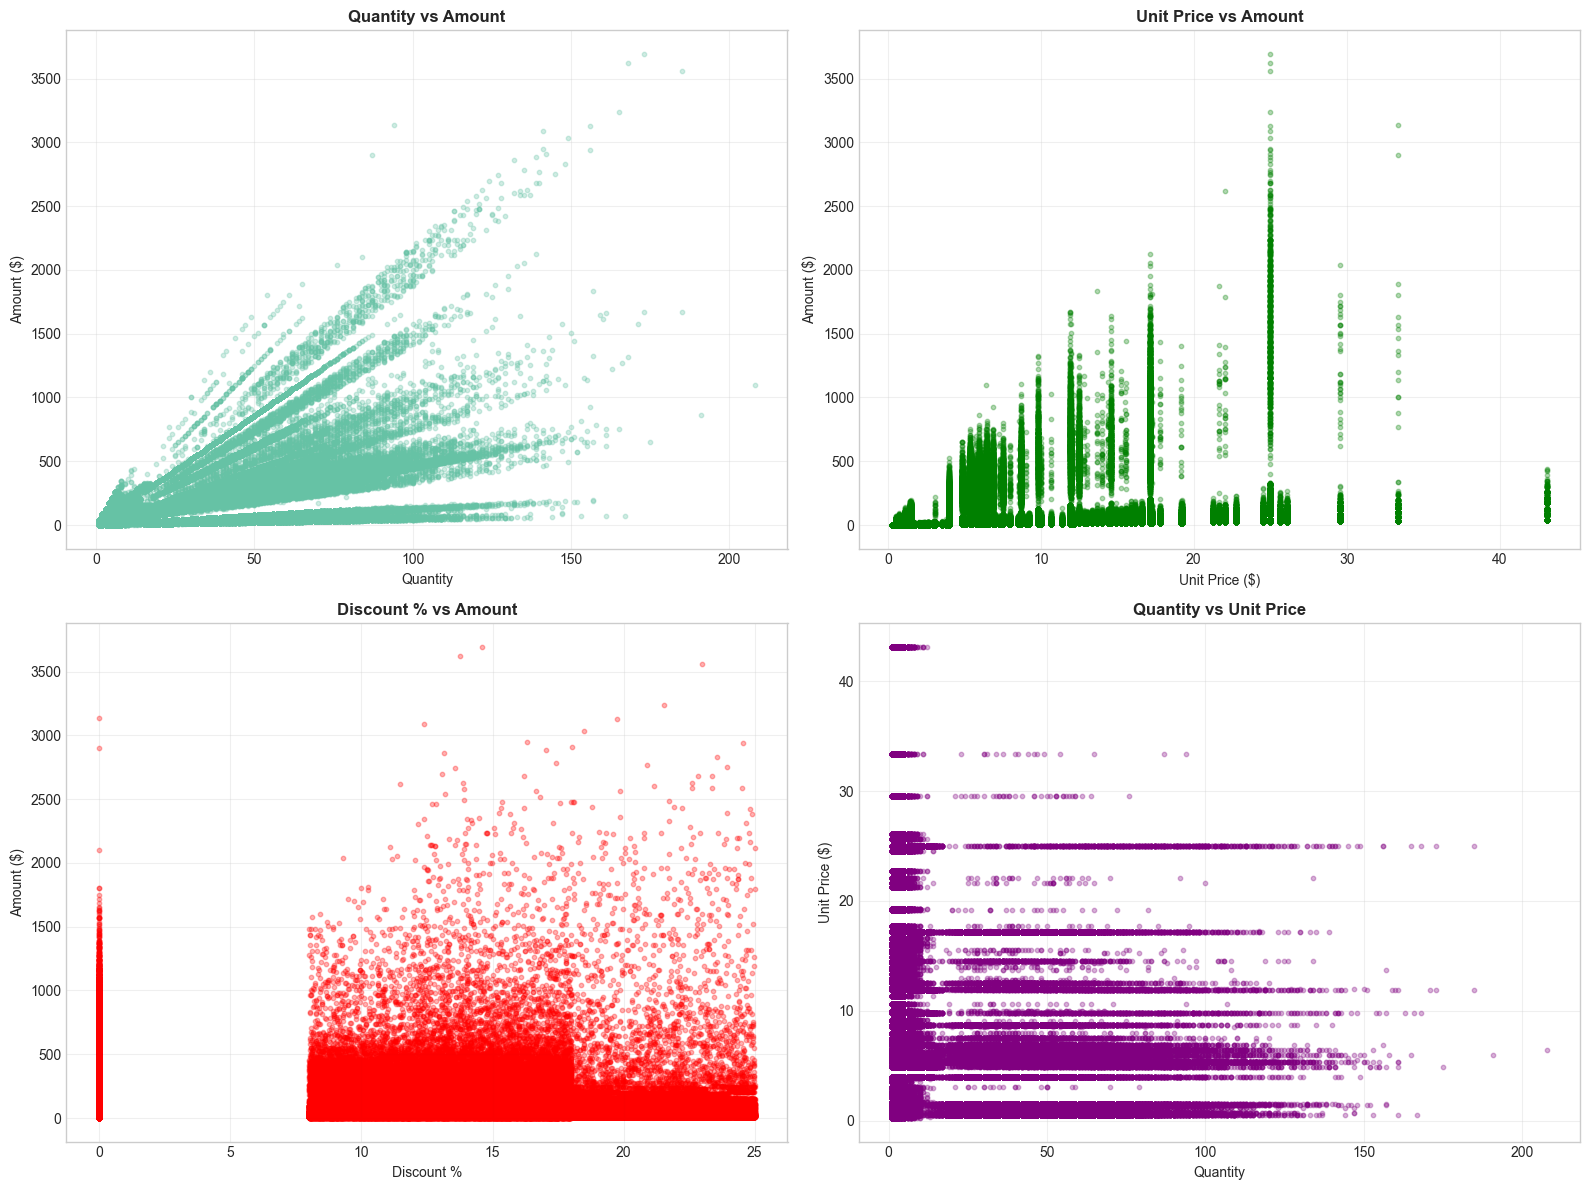

In [28]:
# Scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Quantity vs Amount
axes[0,0].scatter(df['quantity'], df['amount'], alpha=0.3, s=10)
axes[0,0].set_title('Quantity vs Amount', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Quantity')
axes[0,0].set_ylabel('Amount ($)')
axes[0,0].grid(alpha=0.3)

# Unit Price vs Amount
axes[0,1].scatter(df['unit_price'], df['amount'], alpha=0.3, s=10, color='green')
axes[0,1].set_title('Unit Price vs Amount', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Unit Price ($)')
axes[0,1].set_ylabel('Amount ($)')
axes[0,1].grid(alpha=0.3)

# Discount vs Amount
axes[1,0].scatter(df['discount_pct'], df['amount'], alpha=0.3, s=10, color='red')
axes[1,0].set_title('Discount % vs Amount', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Discount %')
axes[1,0].set_ylabel('Amount ($)')
axes[1,0].grid(alpha=0.3)

# Quantity vs Unit Price
axes[1,1].scatter(df['quantity'], df['unit_price'], alpha=0.3, s=10, color='purple')
axes[1,1].set_title('Quantity vs Unit Price', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Quantity')
axes[1,1].set_ylabel('Unit Price ($)')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Key Insights & Summary

In [29]:
# Generate comprehensive summary
print("="*80)
print("KEY INSIGHTS - BEVERAGE SALES ANALYSIS")
print("="*80)

print("\n1. OVERALL PERFORMANCE")
print(f"   - Total Revenue: ${total_revenue:,.2f}")
print(f"   - Total Transactions: {total_transactions:,}")
print(f"   - Total Items Sold: {total_items_sold:,}")
print(f"   - Avg Transaction Value: ${avg_transaction_value:,.2f}")

print("\n2. CATEGORY INSIGHTS")
top_category = category_stats.iloc[0]
print(f"   - Top Category: {top_category['category']}")
print(f"   - Revenue: ${top_category['revenue']:,.2f} ({top_category['revenue']/total_revenue*100:.1f}% of total)")
print(f"   - Units Sold: {top_category['units_sold']:,.0f}")

print("\n3. BRAND INSIGHTS")
top_brand = brand_stats.iloc[0]
print(f"   - Top Brand: {top_brand['brand']}")
print(f"   - Revenue: ${top_brand['revenue']:,.2f}")
print(f"   - Market Share: {top_brand['revenue']/total_revenue*100:.2f}%")

print("\n4. CUSTOMER INSIGHTS")
print(f"   - Total Customers: {df['customer_id'].nunique():,}")
print(f"   - Avg Purchases per Customer: {customer_stats['num_purchases'].mean():.2f}")
print(f"   - Avg Customer Lifetime Value: ${customer_stats['total_spent'].mean():,.2f}")
print(f"   - Avg Order Value: ${customer_stats['avg_order_value'].mean():,.2f}")

print("\n5. TEMPORAL INSIGHTS")
peak_day = weekday_sales.iloc[weekday_sales['total_revenue'].argmax()]
peak_hour = hourly_sales.iloc[hourly_sales['revenue'].argmax()]
print(f"   - Best Day: {peak_day['weekday']} (${peak_day['total_revenue']:,.2f})")
print(f"   - Peak Hour: {int(peak_hour['hour'])}:00 (${peak_hour['revenue']:,.2f})")

print("\n6. DISCOUNT INSIGHTS")
print(f"   - Transactions with Discount: {len(discount_stats):,} ({len(discount_stats)/len(df)*100:.2f}%)")
print(f"   - Avg Discount Applied: {discount_stats['discount_pct'].mean():.2f}%")
print(f"   - Revenue with Discounts: ${discount_stats['amount'].sum():,.2f}")

print("\n7. PRODUCT INSIGHTS")
top_product = product_revenue.iloc[0]
print(f"   - Best-Selling Product: {top_product['product']}")
print(f"   - Revenue: ${top_product['revenue']:,.2f}")
print(f"   - Units Sold: {top_product['units_sold']:,.0f}")

print("\n" + "="*80)

KEY INSIGHTS - BEVERAGE SALES ANALYSIS

1. OVERALL PERFORMANCE
   - Total Revenue: $74,313,273.42
   - Total Transactions: 371,000
   - Total Items Sold: 12,721,147
   - Avg Transaction Value: $200.31

2. CATEGORY INSIGHTS
   - Top Category: beer_cider
   - Revenue: $64,680,511.23 (87.0% of total)
   - Units Sold: 9,113,072

3. BRAND INSIGHTS
   - Top Brand: Club Premium
   - Revenue: $36,231,795.55
   - Market Share: 48.76%

4. CUSTOMER INSIGHTS
   - Total Customers: 53,000
   - Avg Purchases per Customer: 7.00
   - Avg Customer Lifetime Value: $1,402.14
   - Avg Order Value: $134.77

5. TEMPORAL INSIGHTS
   - Best Day: Saturday ($12,038,504.42)
   - Peak Hour: 21:00 ($5,036,256.91)

6. DISCOUNT INSIGHTS
   - Transactions with Discount: 366,834 (20.00%)
   - Avg Discount Applied: 14.42%
   - Revenue with Discounts: $21,334,332.82

7. PRODUCT INSIGHTS
   - Best-Selling Product: Cerveza Club Premium Platino Lata Pack 6 x 355 ml
   - Revenue: $22,905,083.22
   - Units Sold: 4,419,436



## Conclusions

This EDA revealed several actionable insights:

**Sales Performance:**
- Strong revenue concentration in beer & cider category
- High transaction volume with moderate average order values
- Significant revenue contribution from top 20% of products (Pareto principle)

**Customer Behavior:**
- Wide distribution in customer purchase frequency
- Opportunity for customer retention programs targeting high-value customers
- Average customer makes multiple purchases indicating loyalty potential

**Temporal Patterns:**
- Clear daily and weekly seasonality in sales
- Peak hours align with typical shopping patterns
- Weekend vs weekday differences suggest targeted marketing opportunities

**Discount Strategy:**
- Discounts applied to significant portion of transactions
- Impact on transaction values warrants further analysis
- Category-specific discount patterns identified

**Recommendations:**
1. Optimize inventory for top-performing products and brands
2. Implement RFM-based customer segmentation for targeted marketing
3. Review discount strategy effectiveness and ROI
4. Leverage peak hours and days for promotional campaigns
5. Focus on customer retention and loyalty programs for high-value segments